In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_excel('/content/Walmart.xlsx')
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-05-02 00:00:00,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-12-02 00:00:00,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-05-03 00:00:00,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
data.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [5]:
data['Date'] = pd.to_datetime(data['Date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [6]:
data.value_counts()

Store  Date        Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  CPI         Unemployment
45     2012-12-10  734464.36     0             54.47        4.000       192.327265  8.667           1
1      2010-01-10  1453329.50    0             71.89        2.603       211.671989  7.838           1
       2010-02-04  1594968.28    0             62.27        2.719       210.820450  7.808           1
45     2012-07-13  749817.08     0             79.97        3.523       191.168519  8.684           1
       2012-07-09  766512.66     1             75.70        3.911       191.577676  8.684           1
                                                                                                   ..
1      2010-03-19  1472515.79    0             54.58        2.720       211.215635  8.106           1
       2010-03-12  1548033.78    0             49.27        2.708       211.607193  7.838           1
       2010-03-09  1540163.53    0             81.21        2.577       211.531248  7.787           1
       2010-02-26  1409727.59    0             46.63        2.561       211.319643  8.106           1
       2010-02-19  1611968.17    0             39.93        2.514       211.289143  8.106           1
Name: count, Length: 6435, dtype: int64

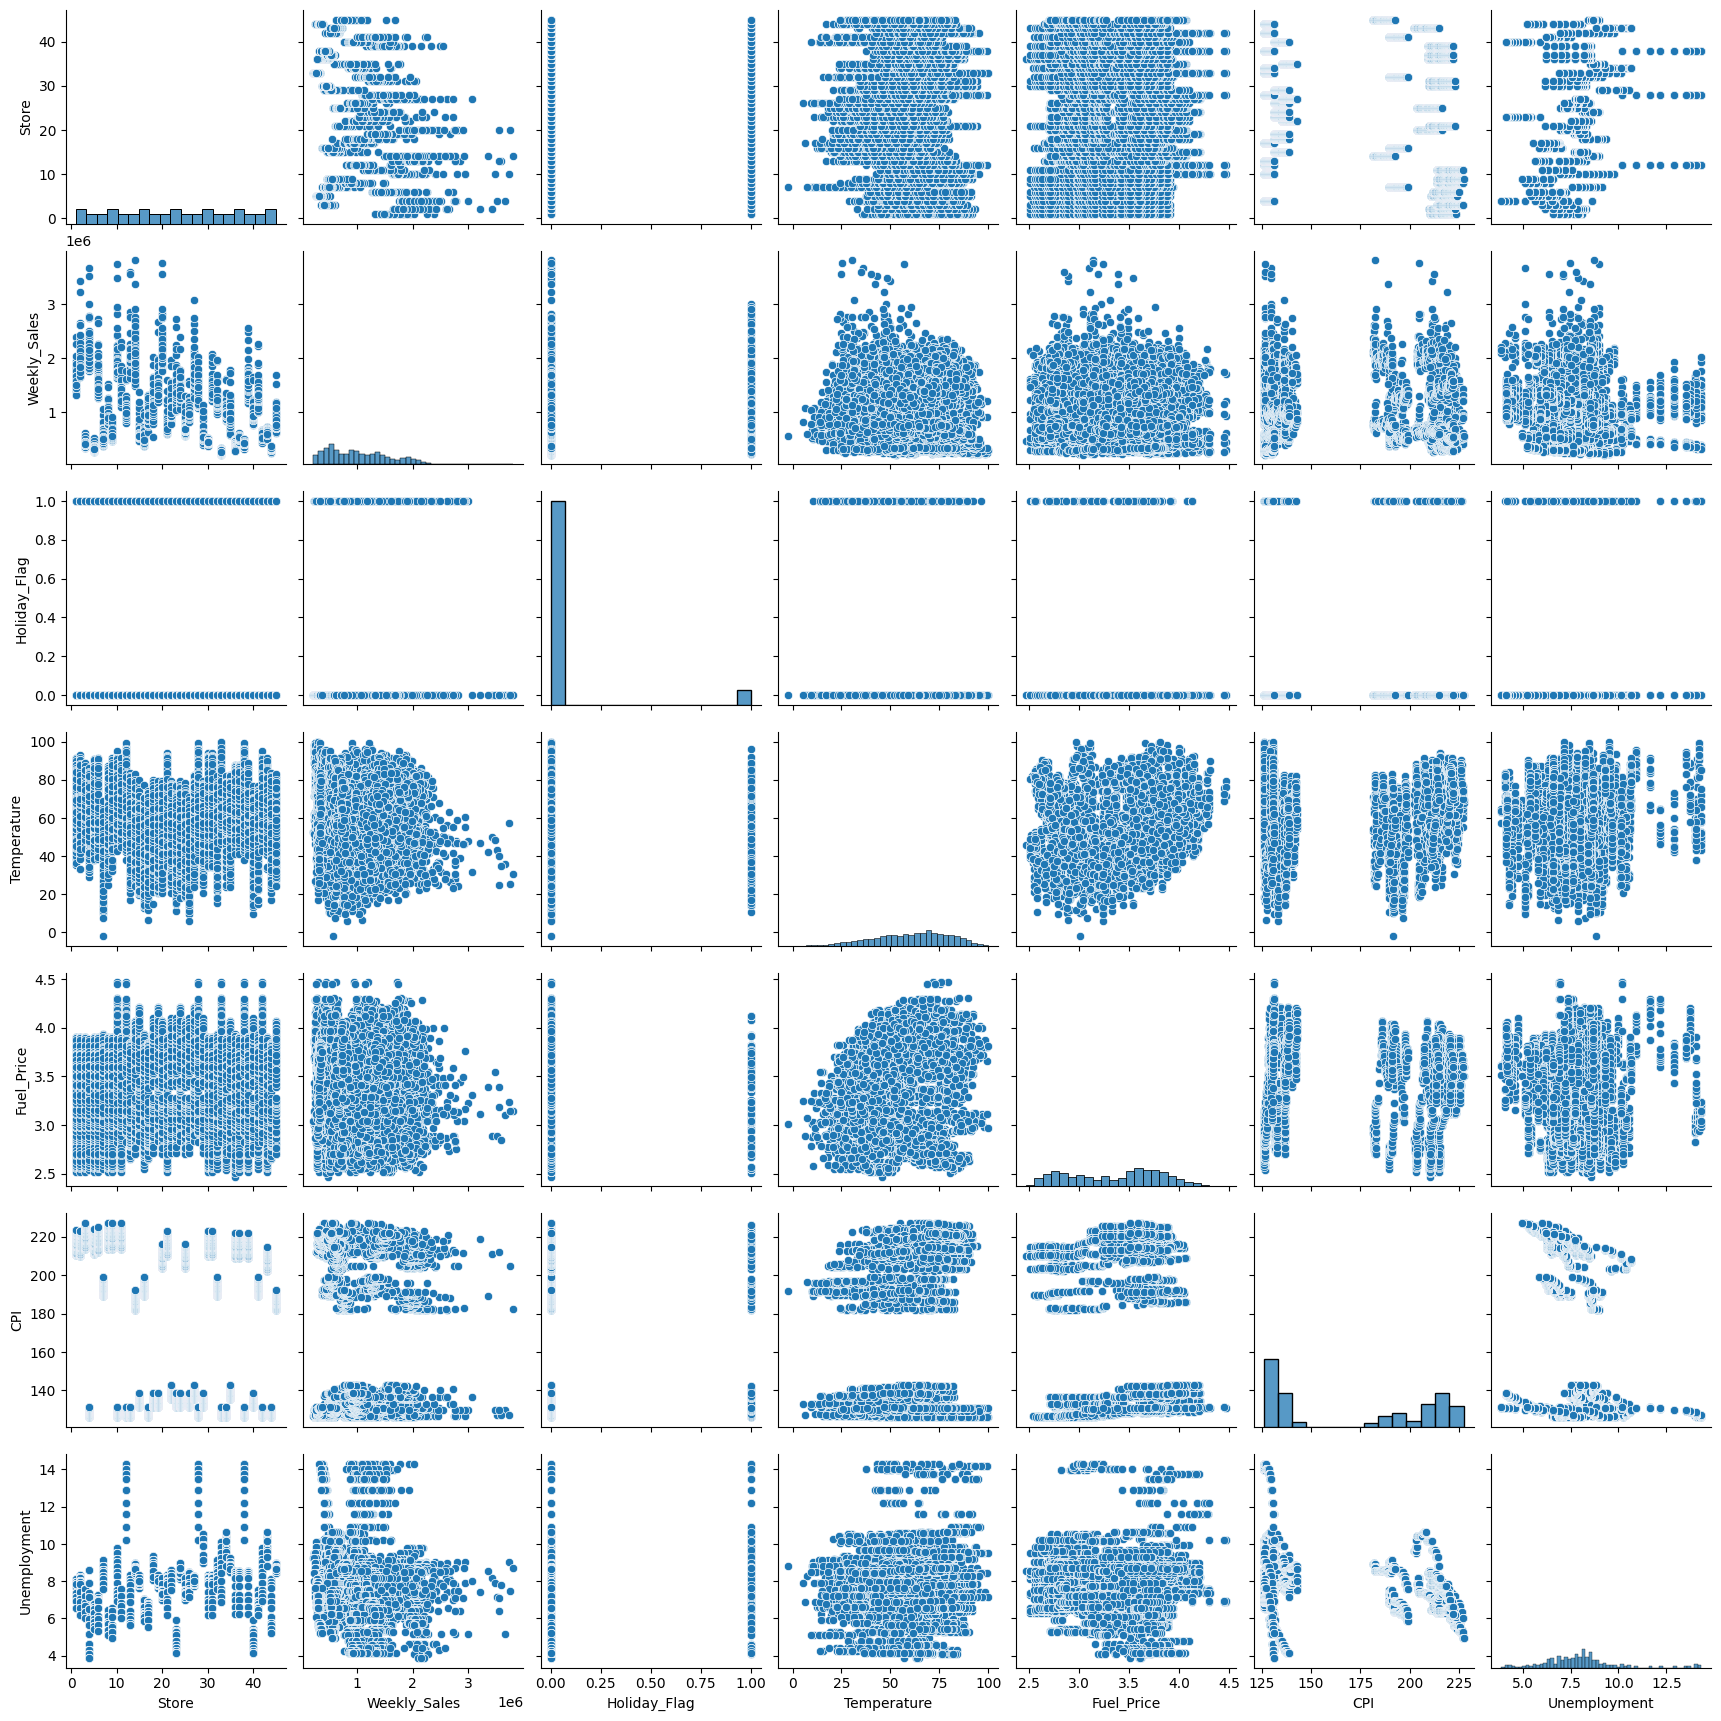

In [7]:
# Pairplot
sns.pairplot(data)
plt.show()

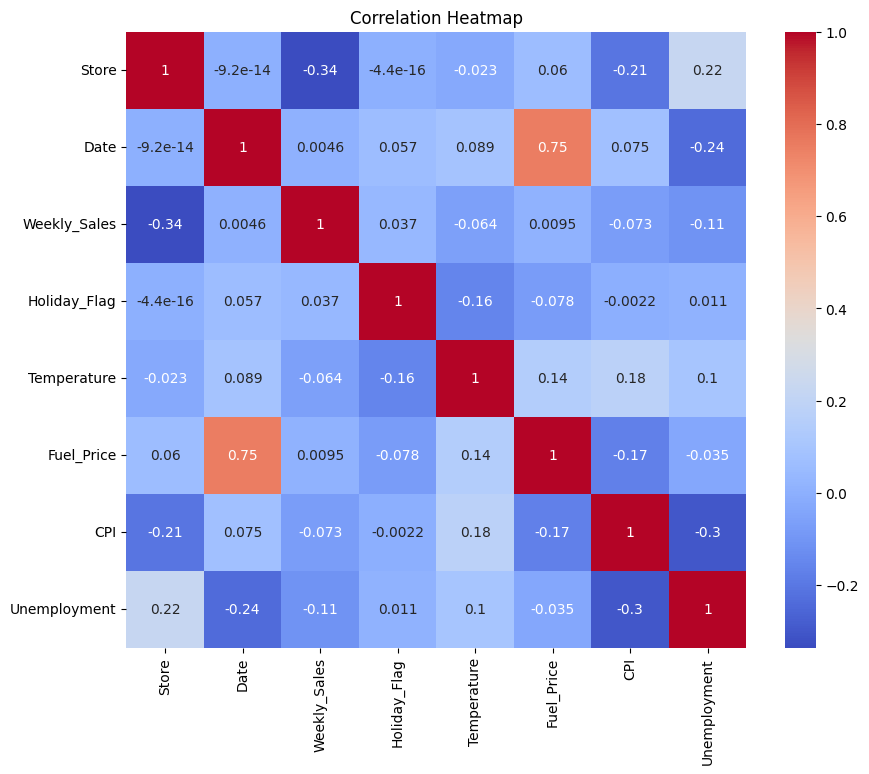

In [8]:
# Heatmap
plt.figure(figsize=(10, 8))  # Adjust figure size if needed
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

* Here we can see Store and Unemployment are corelated
with Corelation coefficient of 0.22

* **And Fuel price are highly corelated with Date having Corelation Coefficient of 0.75**

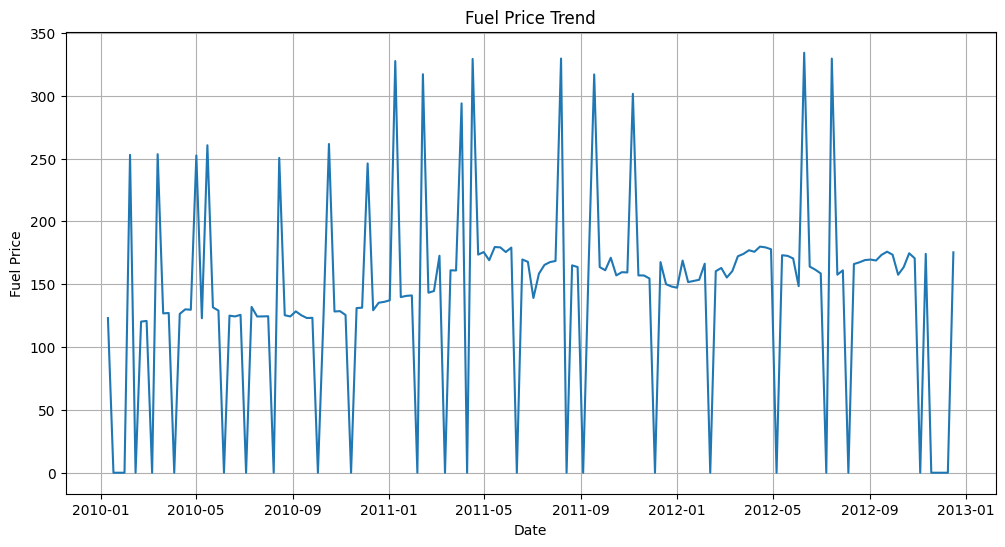

In [16]:
# Group data by week and sum weekly sales
weekly_sales = data.groupby(pd.Grouper(key='Date', freq='W'))['Fuel_Price'].sum().reset_index()

# Plotting weekly sales with date
plt.figure(figsize=(12, 6))
plt.plot(weekly_sales['Date'], weekly_sales['Fuel_Price'])
plt.xlabel('Date')
plt.ylabel('Fuel Price')
plt.title('Fuel Price Trend')
plt.grid(True)
plt.show()




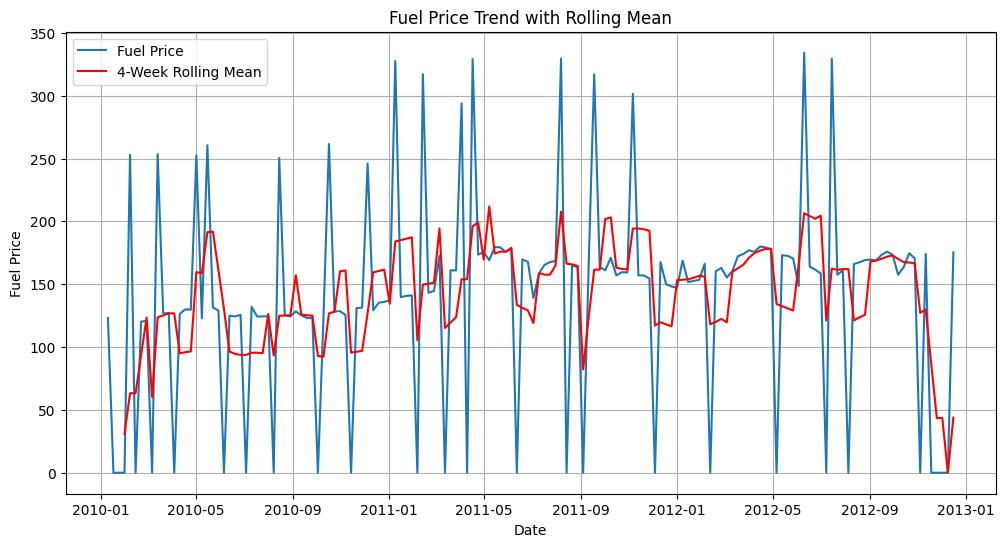

In [17]:
# Calculate rolling mean to visualize trend
weekly_sales['Rolling_Mean'] = weekly_sales['Fuel_Price'].rolling(window=4).mean()  # Adjust window size as needed


# Plotting weekly sales with rolling mean
plt.figure(figsize=(12, 6))
plt.plot(weekly_sales['Date'], weekly_sales['Fuel_Price'], label='Fuel Price')
plt.plot(weekly_sales['Date'], weekly_sales['Rolling_Mean'], label='4-Week Rolling Mean', color='red')
plt.xlabel('Date')
plt.ylabel('Fuel Price')
plt.title('Fuel Price Trend with Rolling Mean')
plt.legend()
plt.grid(True)
plt.show()


* Upward Trend (2010–mid-2012): Fuel prices generally increased, as shown by the rising 4-week rolling mean.

* High Volatility: Weekly prices fluctuated sharply, but the rolling mean smoothed this noise.

* Stabilization Period: Prices stabilized somewhat in 2011–2012.

* Sharp Decline (late 2012): Both actual and average prices dropped significantly, indicating a possible market shift or correction.